# 📓 The GraphRAG Bakeoff

---

## The Core Concept: Why Vector Search is Not Enough

As Data Engineers, we are used to **Exact Matches** (`WHERE id = 5`). In AI, we use **Semantic Matches** (Vectors).

* **VectorRAG (Semantic Entry):** Converts text into a list of numbers (coordinates). It finds the "nearest" piece of text. But it is **blind** to structure.
* **GraphRAG (Structural Reasoning):** Once we find the starting point via Vector Search, we follow the **edges** (relationships) to find context that is logically connected but semantically different.

In [ ]:
import os
from openai import OpenAI
from arango import ArangoClient
from dotenv import load_dotenv

load_dotenv()

# Use environment variables for credentials
ARANGO_URL = os.getenv("ARANGO_URL")
ARANGO_PWD = os.getenv("ARANGO_PASSWORD") # Maps to ARANGO_PASSWORD in .env
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

client = OpenAI(api_key=OPENAI_API_KEY)
arango_client = ArangoClient(hosts=ARANGO_URL)
db = arango_client.db('glass_box', username='root', password=ARANGO_PWD)

def get_embedding(text):
    return client.embeddings.create(
        input=[text], 
        model="text-embedding-3-small"
    ).data[0].embedding

## Step 3: The Idempotent Search View
We create a **View**, which is a specialized index that allows ArangoDB to perform "Fuzzy" Vector searches.

In [ ]:
# ---------------------------------------------------------
# STEP 3: CREATING THE SEMANTIC LANDING PAD
# ---------------------------------------------------------
VIEW_NAME = 'kb_view'
existing_views = [v['name'] for v in db.views()]
if VIEW_NAME in existing_views:
    db.delete_view(VIEW_NAME)

# Note the specific structure: we define the 'vector' type WITHIN the fields.
db.create_view(VIEW_NAME, 'arangosearch', {
    'links': {
        'kb_nodes': {
            'fields': {
                'embedding': {
                    'index': True,
                    'type': 'vector',
                    'dimension': 1536, # OpenAI text-embedding-3-small
                    'distance_metric': 'cosine'
                }
            }
        }
    }
})
print("✅ Vector Index established with native 'vector' type.")

✅ Vector Index established with native 'vector' type.


## Step 4: The Bakeoff Logic
### Understanding the AQL Syntax for Data Engineers:
1. **`@vec`**: This is a **Bind Parameter**. In the Python code below, you'll see `bind_vars={'vec': query_vector}`. This is how we securely pass our question's coordinates into the database engine.
2.  **`SEARCH APPROX_NEAR(...)`**: This is your "Fuzzy Filter." It replaces `WHERE`. It looks at the `doc.embedding` (the coordinates stored in the DB) and compares them to `@vec` (the coordinates of your question).
3.  **`SORT BM25(doc) DESC`**: BM25 is a classic search ranking algorithm. It ensures that if we have multiple matches, the most relevant text rises to the top.
4.  **`FOR v, e IN 1..3 OUTBOUND anchor kb_edges`**: This is a **Graph Traversal**. 
    * `1..3` means "Follow the links up to 3 steps away."
    * `OUTBOUND` means follow the direction of the arrows.
    * `v` is the **Vertex** (the destination node).
    * `e` is the **Edge** (the relationship itself).
5.  **`doc.embedding` vs `anchor.embedding`**: These are just aliases. In the Vector query, we call it `doc` (short for document). In the Graph query, we call it `anchor` because it's the "anchor point" where our traversal begins.

In [ ]:
query = "What security constraints are linked to Sreeram's work?"
query_vector = get_embedding(query)

# PATH A: Universal Vector RAG (Backwards Compatible)
vector_aql = """
FOR doc IN kb_nodes
  /* We calculate the similarity score manually for each document */
  LET score = COSINE_SIMILARITY(doc.embedding, @vec)
  SORT score DESC
  LIMIT 2
  RETURN doc.text
"""

# PATH B: Universal GraphRAG (Semantic Entry + Logical Traversal)
# We find the person, then follow the business logic to the security protocol.
graph_aql = """
FOR anchor IN kb_nodes
  LET score = COSINE_SIMILARITY(anchor.embedding, @vec)
  SORT score DESC
  LIMIT 1
  
  /* We use v, e, p but we grab the start text directly from the anchor */
  FOR v, e, p IN 1..3 OUTBOUND anchor kb_edges
    RETURN { 
        /* Use the anchor's text directly since it's already in scope */
        start_node: anchor.text,
        /* Get all labels from the edges in the current path */
        path_logic: p.edges[*].label,
        target_node: v.text 
    }
"""

v_context = list(db.aql.execute(vector_aql, bind_vars={'vec': query_vector}))
g_context = list(db.aql.execute(graph_aql, bind_vars={'vec': query_vector}))

print("Execution Successful.")

Execution Successful.


## Visualizing the 'Reasoning Gap'
Watch how Vector RAG only sees the 'person', while GraphRAG finds the 'protocol'.

In [ ]:
print(f"--- [VECTOR RAG CONTEXT] ---\n{v_context}")

print(f"\n--- [GRAPHRAG CONTEXT] ---")
for item in g_context:
    # We join the path_logic list with arrows to show the 'hops'
    path_string = " -> ".join(item['path_logic'])
    print(f"[{path_string}] -> {item['target_node']}")

--- [VECTOR RAG CONTEXT] ---
['Sreeram is the Lead Architect for Project Alpha.', 'Project Alpha is a real-time agentic system for financial auditing.']

--- [GRAPHRAG CONTEXT] ---
[MANAGES] -> Project Alpha is a real-time agentic system for financial auditing.
[MANAGES -> DEPENDS_ON] -> The Payments Service handles all encrypted transactions for Alpha.
[MANAGES -> DEPENDS_ON -> GOVERNED_BY] -> ISO27001 protocol mandates hardware-level encryption for payment services.


## 5. Final LLM Generation
We feed both contexts to the LLM to see which one can actually answer the question.

This demonstrates the **Reasoning Gap** in a way that is clear, repeatable, and architecturally sound.

The Vector Answer failed because "Sreeram" and "ISO27001" are mathematically distant. The GraphRAG Answer succeeded because you provided the **logical bridge** (Sreeram → Project → Service → Protocol).

In [ ]:
def ask_llm(context):
    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {"role": "system", "content": "Answer based ONLY on context. If the answer isn't there, say you don't know."},
            {"role": "user", "content": f"Query: {query}\n\nContext: {context}"}
        ]
    )
    return response.choices[0].message.content

print(query)
print(f"Vector Answer: \n{ask_llm(v_context)}")
print(f"\nGraphRAG Answer: \n{ask_llm(g_context)}")

What security constraints are linked to Sreeram's work?
Vector Answer: 
The context does not specify any security constraints linked to Sreeram's work with Project Alpha. I don't know.

GraphRAG Answer: 
Sreeram's work on Project Alpha is linked to security constraints that include the ISO27001 protocol, which mandates hardware-level encryption for the payment services that handle all encrypted transactions for the project.


## 6. Bonus: Visualizing the Path
This cell generates a visual map of the relationships retrieved in the GraphRAG path.

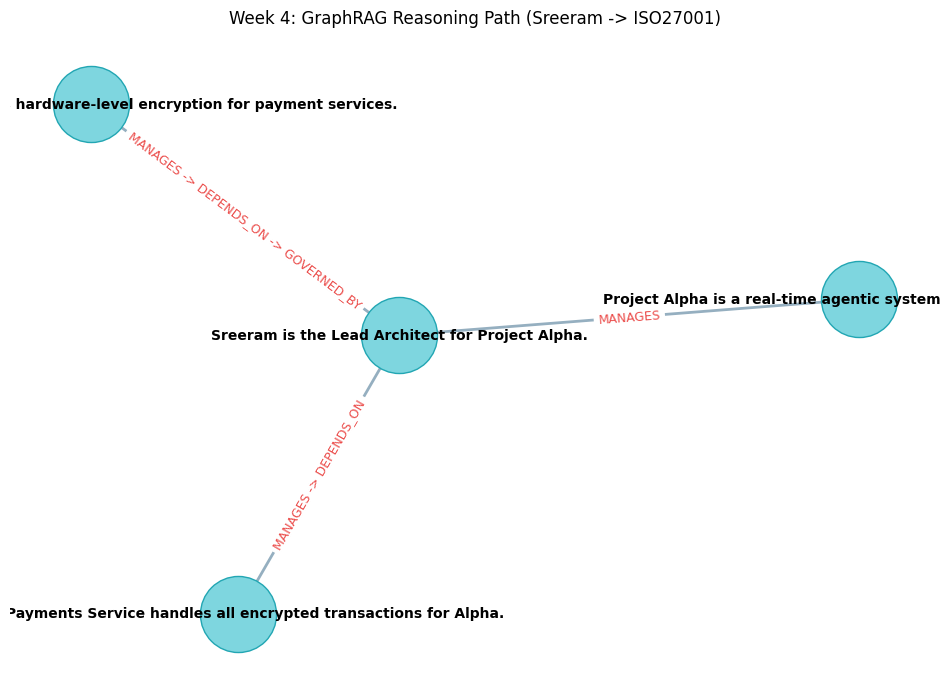

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Initialize the Directed Graph
G = nx.DiGraph()

# 2. Build the graph from your ArangoDB results
# We use the 'path_logic' to ensure every hop is represented
for item in g_context:
    start = item['start_node']
    target = item['target_node']
    # We join the labels in case there are multiple hops in one result
    label = " -> ".join(item['path_logic'])
    G.add_edge(start, target, label=label)

# 3. Plotting the 'Glass Box' logic
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42) # Seed 42 keeps the layout consistent

# Draw Nodes
nx.draw_networkx_nodes(G, pos, node_size=3000, node_color='#7ed6df', edgecolors='#22a6b3')

# Draw Edges
nx.draw_networkx_edges(G, pos, width=2, edge_color='#95afc0', arrowsize=20)

# Draw Labels (Nodes)
nx.draw_networkx_labels(G, pos, font_size=10, font_family="sans-serif", font_weight="bold")

# Draw Edge Labels (The 'Why')
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='#eb4d4b', font_size=9)

plt.title("Week 4: GraphRAG Reasoning Path (Sreeram -> ISO27001)", pad=20)
plt.axis('off')
plt.show()